# preprocessing

In [2]:
import pandas as pd

# Load the train.csv file into a pandas DataFrame
df = pd.read_csv('/content/train.csv')

### Dataset Information
Let's start by looking at the basic information about the dataset, such as data types and non-null values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20886 entries, 0 to 20885
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         20886 non-null  object 
 1   district                          20070 non-null  object 
 2   place_name                        20886 non-null  object 
 3   latitude                          20041 non-null  float64
 4   longitude                         20046 non-null  float64
 5   elevation_m                       20095 non-null  float64
 6   distance_to_river_m               19337 non-null  float64
 7   landcover                         20077 non-null  object 
 8   soil_type                         20073 non-null  object 
 9   water_supply                      20098 non-null  object 
 10  electricity                       19282 non-null  object 
 11  road_quality                      19893 non-null  object 
 12  popu

### Missing Value Percentage
Now, let's calculate the percentage of missing values for each column.

In [4]:
missing_percentage = df.isnull().sum() / len(df) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
display(missing_percentage)

,0
electricity,7.679786
distance_to_river_m,7.416451
distance_to_river_m_log1p,7.416451
ndwi,6.420569
ndwi_qmap,6.420569
drainage_index_yeojohnson,6.296084
drainage_index,6.296084
ndvi,6.037537
ndvi_qmap,6.037537
nearest_hospital_km_log1p,4.898018


In [5]:
missing_values_count = df.isnull().sum()
missing_values_count = missing_values_count[missing_values_count > 0].sort_values(ascending=False)
display(missing_values_count)

,0
electricity,1604
distance_to_river_m,1549
distance_to_river_m_log1p,1549
ndwi,1341
ndwi_qmap,1341
drainage_index_yeojohnson,1315
drainage_index,1315
ndvi,1261
ndvi_qmap,1261
nearest_hospital_km_log1p,1023


### Removing Duplicate Rows

In [6]:
print(f"Shape of DataFrame before removing duplicates: {df.shape}")

df_cleaned = df.drop_duplicates()

print(f"Shape of DataFrame after removing duplicates: {df_cleaned.shape}")

num_duplicates_removed = df.shape[0] - df_cleaned.shape[0]
if num_duplicates_removed > 0:
    print(f"Successfully removed {num_duplicates_removed} duplicate rows.")
else:
    print("No duplicate rows found.")

df = df_cleaned.copy()


Shape of DataFrame before removing duplicates: (20886, 47)
Shape of DataFrame after removing duplicates: (20881, 47)
Successfully removed 5 duplicate rows.


### Removing Unnecessary Variables

In [7]:
columns_to_drop = [
    'record_id',
    'place_name',
    'generation_date',
    'flood_occurrence_current_event',
    'inundation_area_sqm',
    'distance_to_river_m_log1p',
    'population_density_per_km2_log1p',
    'rainfall_7d_mm_log1p',
    'monthly_rainfall_mm_log1p',
    'nearest_hospital_km_log1p',
    'nearest_evac_km_log1p',
    'elevation_m_yeojohnson',
    'drainage_index_yeojohnson',
    'ndvi_qmap',
    'ndwi_qmap',
    'built_up_percent_qmap',
    'is_synthetic',
    'reason_not_good_to_live'
]

print(f"Shape of DataFrame before dropping columns: {df.shape}")

df = df.drop(columns=columns_to_drop, errors='ignore')

print(f"Shape of DataFrame after dropping columns: {df.shape}")


Shape of DataFrame before dropping columns: (20881, 47)
Shape of DataFrame after dropping columns: (20881, 29)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20881 entries, 0 to 20885
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   district                    20065 non-null  object 
 1   latitude                    20036 non-null  float64
 2   longitude                   20041 non-null  float64
 3   elevation_m                 20090 non-null  float64
 4   distance_to_river_m         19332 non-null  float64
 5   landcover                   20072 non-null  object 
 6   soil_type                   20069 non-null  object 
 7   water_supply                20093 non-null  object 
 8   electricity                 19277 non-null  object 
 9   road_quality                19888 non-null  object 
 10  population_density_per_km2  20057 non-null  float64
 11  built_up_percent            20080 non-null  float64
 12  urban_rural                 20082 non-null  object 
 13  rainfall_7d_mm              20062 no

In [9]:
df_pre_imputation = df.copy()

### Missing Data Columns and Counts

In [10]:
missing_values_count = df.isnull().sum()
missing_values_count = missing_values_count[missing_values_count > 0].sort_values(ascending=False)
display(missing_values_count)

,0
electricity,1604
distance_to_river_m,1549
ndwi,1341
drainage_index,1313
ndvi,1260
nearest_hospital_km,1023
road_quality,993
infrastructure_score,970
latitude,845
longitude,840


# Imputation

### Imputation Methods

In [11]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Numerical columns: {list(numerical_cols)}")
print(f"Categorical columns: {list(categorical_cols)}")

Numerical columns: ['latitude', 'longitude', 'elevation_m', 'distance_to_river_m', 'population_density_per_km2', 'built_up_percent', 'rainfall_7d_mm', 'monthly_rainfall_mm', 'drainage_index', 'ndvi', 'ndwi', 'historical_flood_count', 'infrastructure_score', 'nearest_hospital_km', 'nearest_evac_km', 'flood_risk_score', 'seasonal_index', 'terrain_roughness_index', 'socioeconomic_status_index', 'extreme_weather_index']
Categorical columns: ['district', 'landcover', 'soil_type', 'water_supply', 'electricity', 'road_quality', 'urban_rural', 'water_presence_flag', 'is_good_to_live']


#### Installing `fancyimpute` and Imputing Numerical Data with KNN

In [12]:
!pip install fancyimpute

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.5 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29879 sha256=194552200ff4faee387eda95f408b2c6508080105b05925e8149018ad7658954
  Stored in directory: /root/.cache/pip/wheels/df/20/91/e4850b9a31cf660c1bc95515d3bcbc8010e869e5de6d5baf07
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11331 sha256=4ce4ff8d29d973234684d5a457d9ebfa6ffd6311914e826efb861944d6195d3d
  Stored in directory: /root/.cache/pip/wheels/89/11/61/aa5a3167bfff49218cd043a73a83034b9eadd858b0059521be
Successfully built fancyimpute knnimpute


In [13]:
from fancyimpute import KNN
import numpy as np

# Impute numerical columns using KNN
print("Imputing numerical data using KNN...")
df_numerical_imputed = KNN(k=5).fit_transform(df[numerical_cols])
df[numerical_cols] = pd.DataFrame(df_numerical_imputed, columns=numerical_cols, index=df.index)
print("Numerical data imputation complete.")

Imputing numerical data using KNN...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Imputing row 1/20881 with 0 missing, elapsed time: 147.462
Imputing row 101/20881 with 0 missing, elapsed time: 147.471
Imputing row 201/20881 with 0 missing, elapsed time: 147.479
Imputing row 301/20881 with 1 missing, elapsed time: 147.488
Imputing row 401/20881 with 1 missing, elapsed time: 147.500
Imputing row 501/20881 with 0 missing, elapsed time: 147.513
Imputing row 601/20881 with 0 missing, elapsed time: 147.523
Imputing row 701/20881 with 0 missing, elapsed time: 147.534
Imputing row 801/20881 with 0 missing, elapsed time: 147.543
Imputing row 901/20881 with 0 missing, elapsed time: 147.555
Imputing row 1001/20881 with 2 missing, elapsed time: 147.559
Imputing row 1101/20881 with 0 missing, elapsed time: 147.572
Imputing row 1201/20881 with 0 missing, elapsed time: 147.583
Imputing row 1301/20881 with 0 missing, elapsed time: 147.594
Imputing row 1401/20881 with 0 missing, elapsed time: 147.600
Imputing row 1501/20881 with 0 missing, elapsed time: 147.608
Imputing row 1601/20

#### Imputing Categorical Data with MICE

In [14]:
from fancyimpute import IterativeImputer as MICE
import pandas as pd # Ensure pandas is imported
import numpy as np # Ensure numpy is imported

# Identify categorical columns that actually have missing values in the original df
categorical_cols_with_nan = df[categorical_cols].columns[df[categorical_cols].isnull().any()].tolist()

if categorical_cols_with_nan:
    print("Imputing categorical data using MICE...")
    # Create a temporary DataFrame for factorizing and MICE imputation
    df_temp_categorical_factorized = df[categorical_cols_with_nan].copy()

    category_mappings = {}
    for col in categorical_cols_with_nan:
        # Convert object types to 'category' for factorize to work consistently
        df_temp_categorical_factorized[col] = df_temp_categorical_factorized[col].astype('category')

        # Factorize: NaNs become -1
        factorized_data, uniques = pd.factorize(df_temp_categorical_factorized[col])
        category_mappings[col] = uniques

        # Replace -1 (which were NaNs) with np.nan for MICE
        df_temp_categorical_factorized[col] = np.where(factorized_data == -1, np.nan, factorized_data)

    # Apply MICE on the numerical representations with np.nan as missing values
    mice_imputer = MICE(max_iter=10, random_state=42) # default estimator is BayesianRidge
    df_categorical_imputed_array = mice_imputer.fit_transform(df_temp_categorical_factorized)
    df_categorical_imputed = pd.DataFrame(df_categorical_imputed_array, columns=categorical_cols_with_nan, index=df.index)

    # Convert back to original categorical values
    for col in categorical_cols_with_nan:
        # Round the imputed numerical values to get the closest category index
        # Ensure the values are within the valid range before converting to int
        df_categorical_imputed[col] = df_categorical_imputed[col].clip(lower=0, upper=len(category_mappings[col]) - 1).round().astype(int)
        df[col] = category_mappings[col][df_categorical_imputed[col]]
    print("Categorical data imputation complete.")
else:
    print("No missing values in categorical columns to impute.")

Imputing categorical data using MICE...
Categorical data imputation complete.


#### Checking Missing Values After Imputation

In [15]:
missing_after_imputation = df.isnull().sum()
missing_after_imputation = missing_after_imputation[missing_after_imputation > 0].sort_values(ascending=False)

if missing_after_imputation.empty:
    print("No missing values remaining in the DataFrame.")
else:
    display(missing_after_imputation)

No missing values remaining in the DataFrame.


#datasets


### Creating Two Dataframes: Imputed vs. Rows Removed

We will now create two distinct dataframes based on different strategies for handling missing values:

1.  **`df_imputed`**: This dataframe will use the current `df`, which has had its missing numerical values imputed using KNN and categorical values imputed using MICE.
2.  **`df_no_missing_rows`**: This dataframe will be created from the original `df` (before any imputation), where all rows containing *any* missing values are removed.

This will allow for comparison between different missing data handling approaches.

In [16]:
# df after imputation is already available as `df`
df_imputed = df.copy()

# Create df_no_missing_rows by dropping all rows with any missing values from the *original* dataframe
# We'll use the 'df_pre_imputation' state for this, which was saved before any imputation steps.
df_no_missing_rows = df_pre_imputation.dropna()

print(f"Shape of df_imputed (after imputation): {df_imputed.shape}")
print(f"Shape of df_no_missing_rows (after removing rows with NaNs): {df_no_missing_rows.shape}")

Shape of df_imputed (after imputation): (20881, 29)
Shape of df_no_missing_rows (after removing rows with NaNs): (15323, 29)


In [17]:
df_engineered = df_imputed.copy()

## Feature Engineering for `df_engineered`

We will now create a comprehensive set of new features for `df_engineered` to enhance the model's predictive capabilities. These features are designed to capture various aspects of flood risk, including hydrological, terrain, vegetation, urbanization, historical flood patterns, infrastructure, socioeconomic factors, and spatial relationships. Finally, a composite flood index will be created to combine several risk indicators into a single metric.

In [18]:
import numpy as np
from sklearn.cluster import KMeans

# =========================
# HYDROLOGICAL FEATURES
# =========================
df_engineered['rainfall_river_risk'] = (
    df_engineered['rainfall_7d_mm'] / (df_engineered['distance_to_river_m'] + 1)
)
df_engineered['monthly_rainfall_river_risk'] = (
    df_engineered['monthly_rainfall_mm'] / (df_engineered['distance_to_river_m'] + 1)
)
df_engineered['rainfall_drainage_risk'] = (
    df_engineered['rainfall_7d_mm'] * (1 - df_engineered['drainage_index'])
)
df_engineered['monthly_rainfall_drainage_risk'] = (
    df_engineered['monthly_rainfall_mm'] * (1 - df_engineered['drainage_index'])
)
df_engineered['rainfall_elevation_risk'] = (
    df_engineered['rainfall_7d_mm'] / (df_engineered['elevation_m'] + 1)
)
df_engineered['monthly_rainfall_elevation_risk'] = (
    df_engineered['monthly_rainfall_mm'] / (df_engineered['elevation_m'] + 1)
)

# =========================
# TERRAIN FEATURES
# =========================
df_engineered['river_elevation_ratio'] = (
    df_engineered['distance_to_river_m'] / (df_engineered['elevation_m'] + 1)
)
df_engineered['water_accumulation_index'] = (
    df_engineered['ndwi'] * df_engineered['rainfall_7d_mm']
)
df_engineered['water_accumulation_monthly'] = (
    df_engineered['ndwi'] * df_engineered['monthly_rainfall_mm']
)
df_engineered['terrain_water_risk'] = (
    df_engineered['terrain_roughness_index'] * df_engineered['rainfall_7d_mm']
)

# =========================
# VEGETATION FEATURES
# =========================
df_engineered['vegetation_protection'] = (
    df_engineered['ndvi'] * df_engineered['drainage_index']
)
df_engineered['vegetation_water_balance'] = (
    df_engineered['ndvi'] - df_engineered['ndwi']
)
df_engineered['vegetation_rainfall_interaction'] = (
    df_engineered['ndvi'] * df_engineered['rainfall_7d_mm']
)

# =========================
# URBANIZATION FEATURES
# =========================
df_engineered['urban_runoff_index'] = (
    df_engineered['built_up_percent'] * df_engineered['rainfall_7d_mm']
)
df_engineered['urban_runoff_monthly'] = (
    df_engineered['built_up_percent'] * df_engineered['monthly_rainfall_mm']
)
df_engineered['population_pressure'] = (
    df_engineered['population_density_per_km2'] * df_engineered['built_up_percent']
)

# =========================
# HISTORICAL FLOOD FEATURES
# =========================
df_engineered['historical_flood_pressure'] = (
    df_engineered['historical_flood_count'] * df_engineered['rainfall_7d_mm']
)
df_engineered['historical_vulnerability'] = (
    df_engineered['historical_flood_count'] / (df_engineered['distance_to_river_m'] + 1)
)
df_engineered['historical_elevation_risk'] = (
    df_engineered['historical_flood_count'] / (df_engineered['elevation_m'] + 1)
)

# =========================
# INFRASTRUCTURE FEATURES
# =========================
df_engineered['infra_vulnerability'] = (
    (100 - df_engineered['infrastructure_score']) * df_engineered['rainfall_7d_mm']
)
df_engineered['hospital_access_risk'] = (
    df_engineered['nearest_hospital_km'] * df_engineered['historical_flood_count']
)
df_engineered['evacuation_access_risk'] = (
    df_engineered['nearest_evac_km'] * df_engineered['historical_flood_count']
)

# =========================
# SOCIOECONOMIC FEATURES
# =========================
df_engineered['socioeconomic_flood_risk'] = (
    df_engineered['socioeconomic_status_index'] * df_engineered['historical_flood_count']
)
df_engineered['weather_vulnerability'] = (
    df_engineered['extreme_weather_index'] * df_engineered['historical_flood_count']
)
df_engineered['weather_rainfall_interaction'] = (
    df_engineered['extreme_weather_index'] * df_engineered['rainfall_7d_mm']
)

# =========================
# SPATIAL FEATURES
# =========================
kmeans = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=10 # Explicitly set n_init for KMeans
)
df_engineered['location_cluster'] = kmeans.fit_predict(
    df_engineered[['latitude', 'longitude']]
)

# =========================
# DISTANCE FEATURES
# =========================
df_engineered['hospital_river_ratio'] = (
    df_engineered['nearest_hospital_km'] / (df_engineered['distance_to_river_m'] + 1)
)
df_engineered['evac_river_ratio'] = (
    df_engineered['nearest_evac_km'] / (df_engineered['distance_to_river_m'] + 1)
)

# =========================
# COMBINED FLOOD INDEX
# =========================
df_engineered['composite_flood_index'] = (
    (
        df_engineered['rainfall_7d_mm']
        * df_engineered['historical_flood_count']
        * (1 + df_engineered['ndwi'])
    )
    /
    (
        (df_engineered['distance_to_river_m'] + 1)
        * (df_engineered['elevation_m'] + 1)
    )
)

print(f"New shape of df_engineered: {df_engineered.shape}")
print("Feature engineering for df_engineered completed successfully!")

New shape of df_engineered: (20881, 58)
Feature engineering for df_engineered completed successfully!


# EDA




### Distribution of Flood Risk Score (Imputed Data)

Let's visualize the distribution of the target variable, `flood_risk_score`, using a histogram. This will help us understand its spread, central tendency, and any potential skewness or outliers.

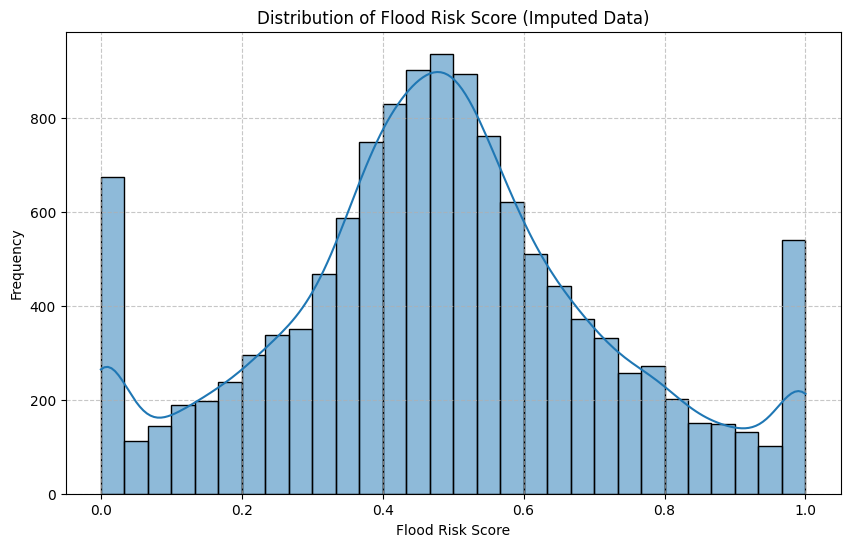

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_imputed['flood_risk_score'], kde=True, bins=30)
plt.title('Distribution of Flood Risk Score (Imputed Data)')
plt.xlabel('Flood Risk Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Correlation Matrix (Imputed Data)

Let's visualize the correlation matrix for the numerical features in the `df_imputed` dataset. This helps in understanding the linear relationships between different variables, which can be useful for feature selection and model interpretation. We'll use a heatmap for better visualization.

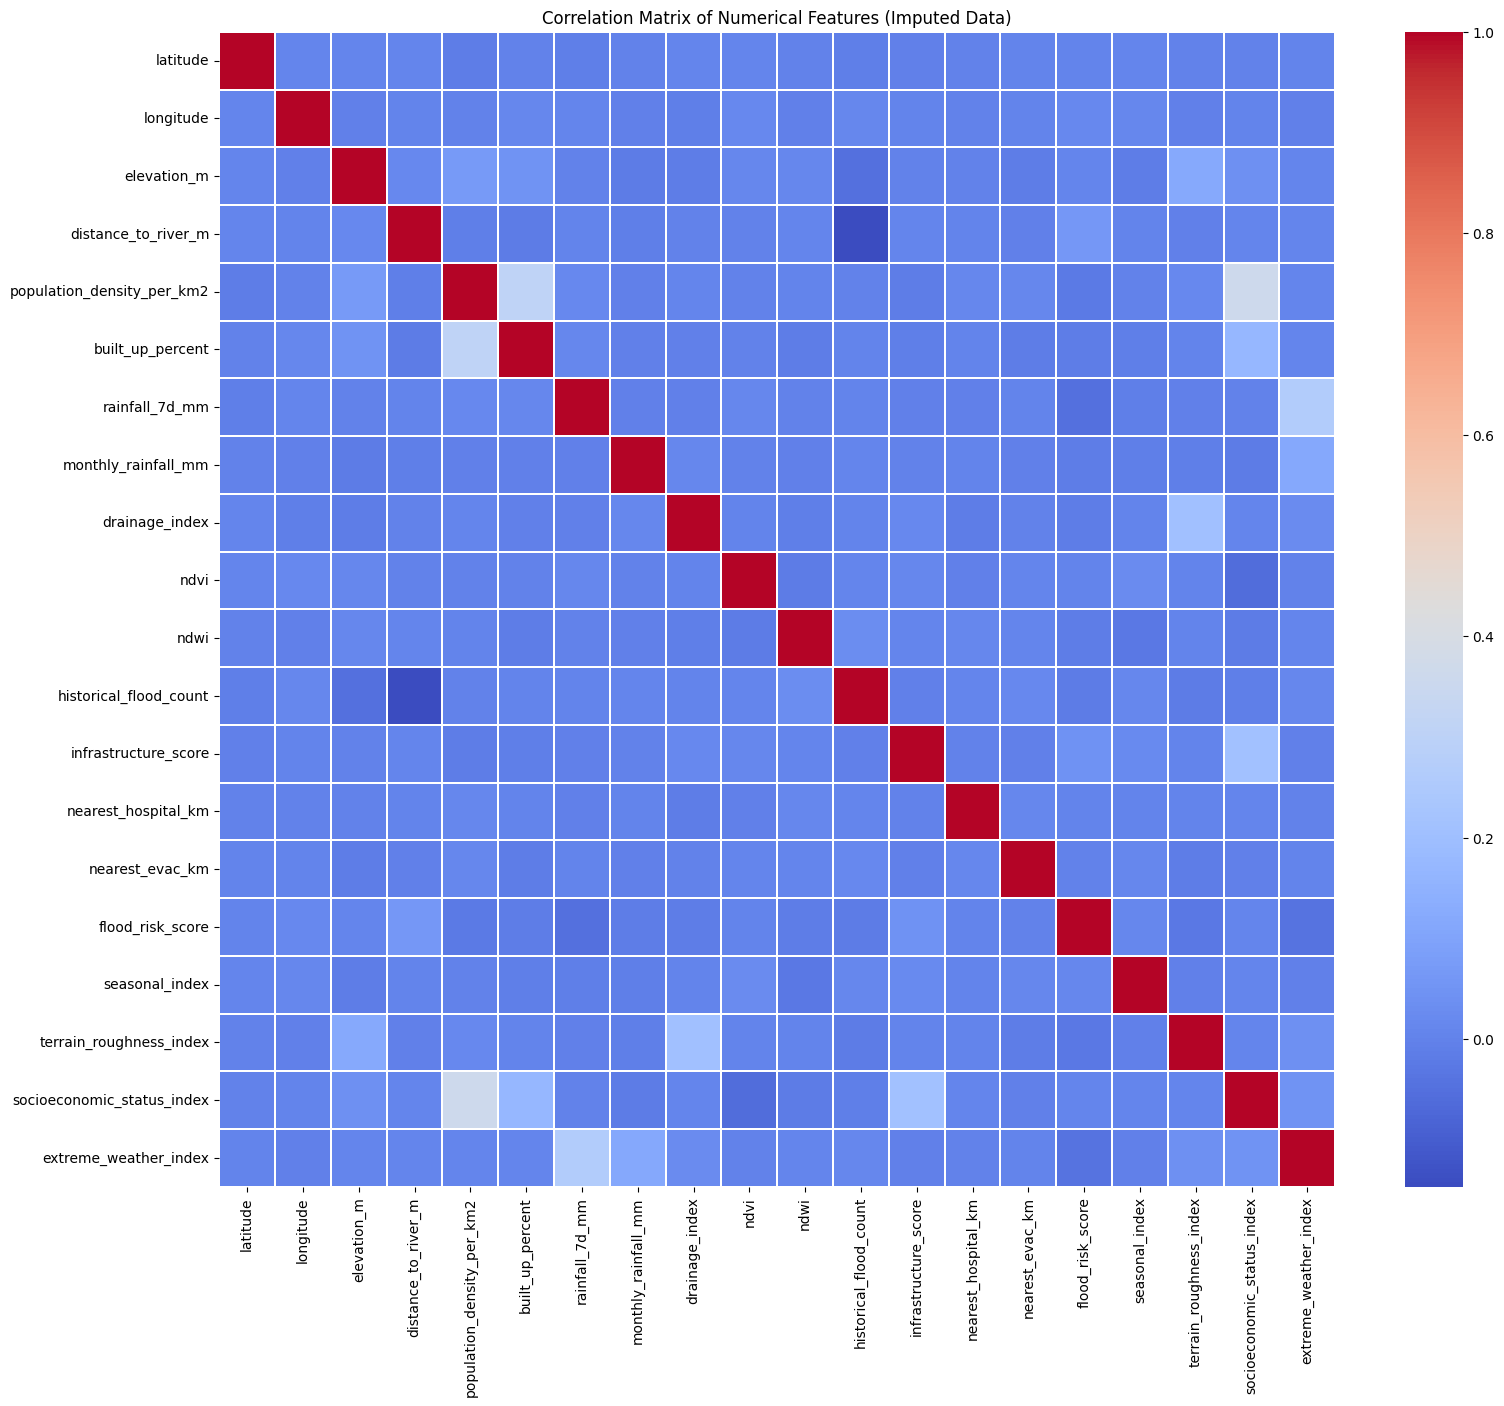

In [ ]:
plt.figure(figsize=(18, 15))
sns.heatmap(df_imputed[numerical_cols].corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Matrix of Numerical Features (Imputed Data)')
plt.show()

### Correlation Matrix (Engineered Data)

Now, let's visualize the correlation matrix for the numerical features in the `df_engineered` dataset. This will help us understand the relationships between the original features, the imputed features, and the newly engineered features.

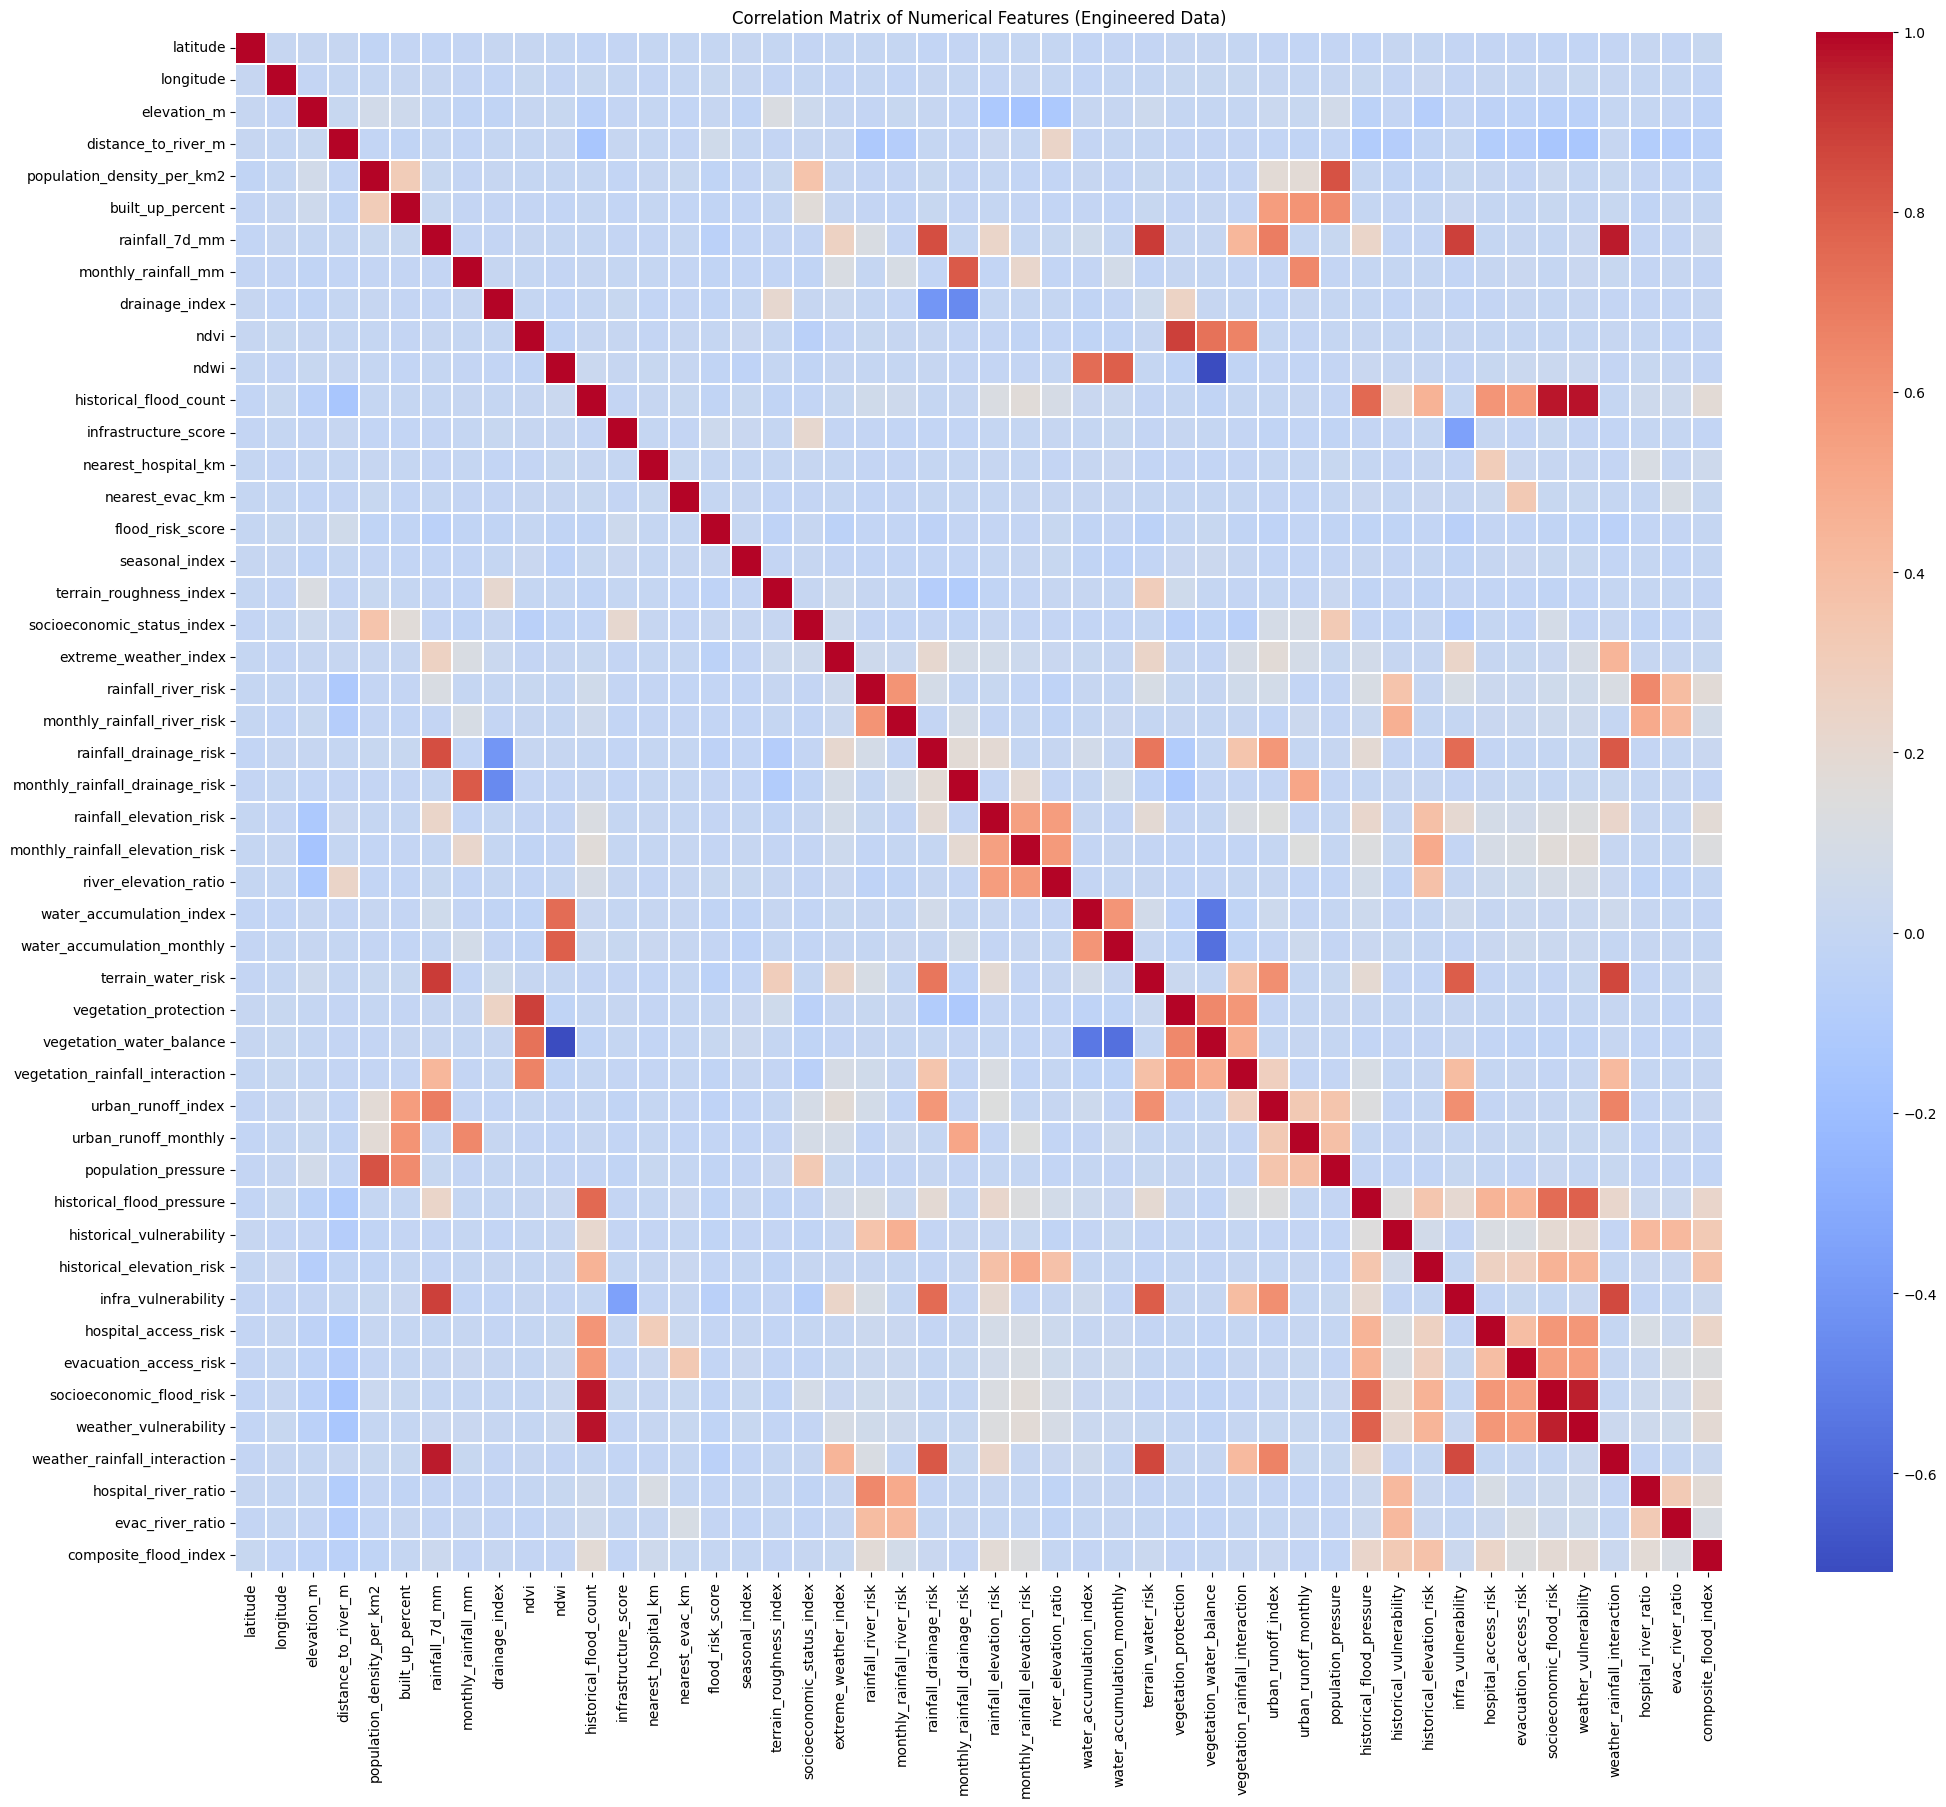

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns in df_engineered
numerical_cols_engineered = df_engineered.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(24, 20)) # Adjust figure size for more features
sns.heatmap(df_engineered[numerical_cols_engineered].corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Matrix of Numerical Features (Engineered Data)')
plt.show()

# clustering

In [19]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) for the imputed dataset
X_imputed = df_imputed.drop('flood_risk_score', axis=1)
y_imputed = df_imputed['flood_risk_score']

# Split the imputed data into training and testing sets (80% train, 20% test)
X_train_imputed, X_test_imputed, y_train_imputed, y_test_imputed = train_test_split(
    X_imputed, y_imputed, test_size=0.2, random_state=42
)

print(f"Shape of X_train_imputed: {X_train_imputed.shape}")
print(f"Shape of X_test_imputed: {X_test_imputed.shape}")
print(f"Shape of y_train_imputed: {y_train_imputed.shape}")
print(f"Shape of y_test_imputed: {y_test_imputed.shape}")

Shape of X_train_imputed: (16704, 28)
Shape of X_test_imputed: (4177, 28)
Shape of y_train_imputed: (16704,)
Shape of y_test_imputed: (4177,)


## K-Prototypes Clustering

To find significant clusters in the training data (`X_train_imputed`), we will use the K-Prototypes clustering algorithm. This algorithm is suitable for datasets containing a mix of numerical and categorical features. We will first determine an optimal number of clusters using the elbow method.

In [20]:
# Install kmodes library if not already installed
!pip install kmodes -qq

### Preparing Data for K-Prototypes

The K-Prototypes algorithm requires separating numerical and categorical features. We'll identify these columns in `X_train_imputed` and extract them.

In [21]:
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical and categorical columns in X_train_imputed
# Reuse the lists from earlier steps for consistency
categorical_cols_X_train = X_imputed.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols_X_train = X_imputed.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Get the indices of categorical columns within X_train_imputed
# This is crucial for KPrototypes to know which columns are categorical
cat_indices = [X_train_imputed.columns.get_loc(col) for col in categorical_cols_X_train if col in X_train_imputed.columns]

print(f"Categorical columns for K-Prototypes: {categorical_cols_X_train}")
print(f"Numerical columns for K-Prototypes: {numerical_cols_X_train}")
print(f"Indices of categorical columns: {cat_indices}")

Categorical columns for K-Prototypes: ['district', 'landcover', 'soil_type', 'water_supply', 'electricity', 'road_quality', 'urban_rural', 'water_presence_flag', 'is_good_to_live']
Numerical columns for K-Prototypes: ['latitude', 'longitude', 'elevation_m', 'distance_to_river_m', 'population_density_per_km2', 'built_up_percent', 'rainfall_7d_mm', 'monthly_rainfall_mm', 'drainage_index', 'ndvi', 'ndwi', 'historical_flood_count', 'infrastructure_score', 'nearest_hospital_km', 'nearest_evac_km', 'seasonal_index', 'terrain_roughness_index', 'socioeconomic_status_index', 'extreme_weather_index']
Indices of categorical columns: [0, 5, 6, 7, 8, 9, 12, 18, 23]


### Determining Optimal Number of Clusters (Elbow Method)

We will use the elbow method to find a suitable number of clusters (K). We'll run K-Prototypes for a range of K values and plot the cost (sum of squared distances to centroids). The 'elbow' point in the plot usually indicates a good balance between minimizing cost and limiting the number of clusters.

K-Prototypes for k=1 completed with cost: 73000332442.26
K-Prototypes for k=2 completed with cost: 32928036660.76
K-Prototypes for k=3 completed with cost: 20585962410.42


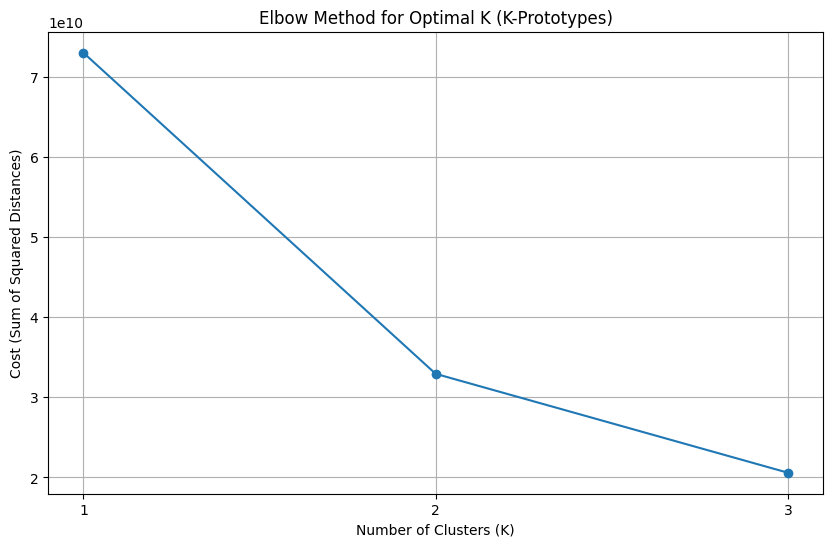

In [23]:
costs = []
K_range = range(1, 4) # Test for K from 1 to 10

# Convert X_train_imputed to numpy array for KPrototypes
X_train_array = X_train_imputed.values

for k in K_range:
    try:
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=5, random_state=42, n_jobs=-1)
        kproto.fit(X_train_array, categorical=cat_indices)
        costs.append(kproto.cost_)
        print(f"K-Prototypes for k={k} completed with cost: {kproto.cost_:.2f}")
    except Exception as e:
        print(f"Error with k={k}: {e}")
        costs.append(np.nan) # Append NaN if an error occurs

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, costs, marker='o')
plt.title('Elbow Method for Optimal K (K-Prototypes)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Cost (Sum of Squared Distances)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

### Applying K-Prototypes with a Selected K

Based on the elbow plot, we can select an optimal number of clusters. For demonstration, let's assume `K=4` as a starting point (you can adjust this after reviewing the elbow plot). We will then apply K-Prototypes to `X_train_imputed` and add the cluster labels to the training data.

In [24]:
# Choose an optimal K based on the elbow plot (e.g., K=4 for demonstration)
optimal_k = 3 # Adjust this value after reviewing the elbow plot

print(f"Applying K-Prototypes with optimal_k={optimal_k}...")
kproto_final = KPrototypes(n_clusters=optimal_k, init='Huang', n_init=5, random_state=42, n_jobs=-1)
clusters = kproto_final.fit_predict(X_train_array, categorical=cat_indices)

# Add the cluster labels to the X_train_imputed DataFrame
X_train_imputed_clustered = X_train_imputed.copy()
X_train_imputed_clustered['cluster_label'] = clusters

print(f"K-Prototypes clustering complete with {optimal_k} clusters.")
print("Distribution of cluster labels in X_train_imputed:")
display(X_train_imputed_clustered['cluster_label'].value_counts().sort_index())

print("First 5 rows of X_train_imputed with cluster labels:")
display(X_train_imputed_clustered.head())

Applying K-Prototypes with optimal_k=3...
K-Prototypes clustering complete with 3 clusters.
Distribution of cluster labels in X_train_imputed:


,count
cluster_label,
0,10019
1,1173
2,5512


First 5 rows of X_train_imputed with cluster labels:


,district,latitude,longitude,elevation_m,distance_to_river_m,landcover,soil_type,water_supply,electricity,road_quality,...,historical_flood_count,infrastructure_score,nearest_hospital_km,nearest_evac_km,is_good_to_live,seasonal_index,terrain_roughness_index,socioeconomic_status_index,extreme_weather_index,cluster_label
10612,Nuwara Eliya,9.503618,81.224894,672.0,375.2,Scrub,Clay,Surface water,Grid,Poor (unpaved),...,0.0,49.0,19.38,2.93,No,-1.043559,0.922143,0.452619,0.711164,0
401,Mannar,7.908540,81.470658,16.0,2820.1,Urban,Clay,Well,Mixed,No road access,...,0.0,20.0,18.90,13.76,No,-0.462179,0.661385,0.373930,0.763899,2
6482,Jaffna,8.147007,81.860906,42.0,3043.0,Urban,Peaty,Municipal,Grid,Good (paved),...,0.0,67.0,12.79,2.23,No,0.979569,0.850163,0.605062,0.759868,2
20417,Galle,5.990197,81.633699,15.0,359.0,Forest,Sandy,Tube-well,Grid,Good (paved),...,0.0,93.0,5.77,2.47,Yes,-0.953086,0.703428,0.502902,0.843927,0
8086,Jaffna,8.447751,80.935084,50.0,2651.0,Urban,Sandy,Well,Grid,Fair,...,0.0,33.0,4.20,0.72,Yes,-1.103799,0.691878,0.679432,0.774809,2


### Applying K-Prototypes to the Test Set

Now, we will use the trained K-Prototypes model to assign cluster labels to the `X_test_imputed` dataset. This ensures that the clusters are consistent with those found in the training data.

In [25]:
import numpy as np

# Convert X_test_imputed to numpy array for KPrototypes
X_test_array = X_test_imputed.values

# Predict clusters for the test set using the trained kproto_final model
clusters_test = kproto_final.predict(X_test_array, categorical=cat_indices)

# Add the cluster labels to the X_test_imputed DataFrame
X_test_imputed_clustered = X_test_imputed.copy()
X_test_imputed_clustered['cluster_label'] = clusters_test

print(f"K-Prototypes clustering complete for the test set with {optimal_k} clusters.")
print("Distribution of cluster labels in X_test_imputed:")
display(X_test_imputed_clustered['cluster_label'].value_counts().sort_index())

print("First 5 rows of X_test_imputed with cluster labels:")
display(X_test_imputed_clustered.head())

K-Prototypes clustering complete for the test set with 3 clusters.
Distribution of cluster labels in X_test_imputed:


,count
cluster_label,
0,2470
1,329
2,1378


First 5 rows of X_test_imputed with cluster labels:


,district,latitude,longitude,elevation_m,distance_to_river_m,landcover,soil_type,water_supply,electricity,road_quality,...,historical_flood_count,infrastructure_score,nearest_hospital_km,nearest_evac_km,is_good_to_live,seasonal_index,terrain_roughness_index,socioeconomic_status_index,extreme_weather_index,cluster_label
4955,Ratnapura,9.215185,80.748703,69.000000,2607.200000,Scrub,Peaty,Municipal,Grid,Good (paved),...,0.0,5.000000,7.240000,3.55,No,-0.882753,0.681383,0.317665,0.562510,2
5195,Nuwara Eliya,7.722054,81.373394,999.000000,974.500000,Urban,Clay,Surface water,Grid,Good (paved),...,0.0,44.000000,0.780000,4.73,No,1.042783,0.571395,0.673575,0.683712,0
19084,Mannar,7.391973,80.004693,77.000000,8358.900000,Agriculture,Peaty,Surface water,Grid,Good (paved),...,0.0,62.000000,13.322089,15.49,No,0.841332,0.705936,0.408219,0.694975,1
18598,Nuwara Eliya,7.987586,81.184904,81.019504,1964.645866,Urban,Silty,Well,Grid,Fair,...,0.0,32.852348,8.027282,3.18,No,-0.129045,0.586658,0.342678,0.668681,2
20002,Mannar,7.352909,81.122818,55.000000,2444.479744,Scrub,Silty,Municipal,Grid,Poor (unpaved),...,0.0,60.000000,11.300000,13.09,No,-1.050263,0.558443,0.518212,0.645163,2


building models for clusters


## Model Training and Evaluation by Cluster

We will now proceed with building and evaluating models for each identified cluster. For each cluster, we will:

1.  **Split Data:** Separate the training and testing data specific to that cluster.
2.  **Feature Encoding:** Apply one-hot encoding to categorical features within the cluster's data.
3.  **Model Selection:** Use XGBoost, CatBoost, and LightGBM.
4.  **Hyperparameter Tuning:** Utilize `RandomizedSearchCV` with 3-fold cross-validation to find the best hyperparameters for each model.
5.  **Evaluation:** Evaluate the best-tuned model on both the training and testing sets, reporting R-squared, RMSE, and MAE.

In [27]:
# Install required libraries if not already installed
!pip install xgboost lightgbm catboost -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.5 MB/s eta 0:00:00


In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from scipy.stats import randint, uniform

# Define evaluation metrics
def rmmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Function to evaluate a model and print metrics
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, cluster_id):
    print(f"\n--- Evaluating Tuned {model_name} Model for {cluster_id} ---")

    # Predictions on training set
    y_train_pred = model.predict(X_train)
    train_rmmse = rmmse(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # Predictions on test set
    y_test_pred = model.predict(X_test)
    test_rmmse = rmmse(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"Train RMMSE: {train_rmmse:.4f}")
    print(f"Test RMMSE: {test_rmmse:.4f}")
    print(f"Train MAE: {train_mae:.4f}")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Train R^2: {train_r2:.4f}")
    print(f"Test R^2: {test_r2:.4f}")

    return {
        'Train RMMSE': train_rmmse,
        'Test RMMSE': test_rmmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train R^2': train_r2,
        'Test R^2': test_r2,
    }

### Define Hyperparameter Distributions

We define the hyperparameter search spaces for XGBoost, CatBoost, and LightGBM using `scipy.stats` distributions for `RandomizedSearchCV`.

In [29]:
# Define hyperparameter distributions for XGBoost
param_dist_xgb = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

# Define hyperparameter distributions for LightGBM
param_dist_lgbm = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'num_leaves': randint(20, 60)
}

# Define hyperparameter distributions for CatBoost
param_dist_cb = {
    'iterations': randint(100, 300),
    'learning_rate': uniform(0.03, 0.07),
    'depth': randint(4, 8),
    'l2_leaf_reg': randint(1, 6)
}

print("Hyperparameter distributions for XGBoost, CatBoost, and LightGBM defined.")

Hyperparameter distributions for XGBoost, CatBoost, and LightGBM defined.


### Integrate Cluster Labels into Feature-Selected DataFrames

Before proceeding with cluster-specific modeling, we need to add the `cluster_label` column to the `X_train_imputed_selected` and `X_test_imputed_selected` dataframes. These dataframes already contain the features selected based on Mutual Information.

In [32]:
# Add cluster labels to the feature-selected training data
X_train_imputed_selected_with_clusters = X_train_imputed_clustered.copy()
X_train_imputed_selected_with_clusters['cluster_label'] = X_train_imputed_clustered['cluster_label']

# Add cluster labels to the feature-selected testing data
X_test_imputed_selected_with_clusters = X_test_imputed_clustered.copy()
X_test_imputed_selected_with_clusters['cluster_label'] = X_test_imputed_clustered['cluster_label']

print("Cluster labels integrated into X_train_imputed_selected_with_clusters and X_test_imputed_selected_with_clusters.")
print(f"Shape of X_train_imputed_selected_with_clusters: {X_train_imputed_selected_with_clusters.shape}")
print(f"Shape of X_test_imputed_selected_with_clusters: {X_test_imputed_selected_with_clusters.shape}")

display(X_train_imputed_selected_with_clusters.head())
display(X_test_imputed_selected_with_clusters.head())

Cluster labels integrated into X_train_imputed_selected_with_clusters and X_test_imputed_selected_with_clusters.
Shape of X_train_imputed_selected_with_clusters: (16704, 29)
Shape of X_test_imputed_selected_with_clusters: (4177, 29)


,district,latitude,longitude,elevation_m,distance_to_river_m,landcover,soil_type,water_supply,electricity,road_quality,...,historical_flood_count,infrastructure_score,nearest_hospital_km,nearest_evac_km,is_good_to_live,seasonal_index,terrain_roughness_index,socioeconomic_status_index,extreme_weather_index,cluster_label
10612,Nuwara Eliya,9.503618,81.224894,672.0,375.2,Scrub,Clay,Surface water,Grid,Poor (unpaved),...,0.0,49.0,19.38,2.93,No,-1.043559,0.922143,0.452619,0.711164,0
401,Mannar,7.908540,81.470658,16.0,2820.1,Urban,Clay,Well,Mixed,No road access,...,0.0,20.0,18.90,13.76,No,-0.462179,0.661385,0.373930,0.763899,2
6482,Jaffna,8.147007,81.860906,42.0,3043.0,Urban,Peaty,Municipal,Grid,Good (paved),...,0.0,67.0,12.79,2.23,No,0.979569,0.850163,0.605062,0.759868,2
20417,Galle,5.990197,81.633699,15.0,359.0,Forest,Sandy,Tube-well,Grid,Good (paved),...,0.0,93.0,5.77,2.47,Yes,-0.953086,0.703428,0.502902,0.843927,0
8086,Jaffna,8.447751,80.935084,50.0,2651.0,Urban,Sandy,Well,Grid,Fair,...,0.0,33.0,4.20,0.72,Yes,-1.103799,0.691878,0.679432,0.774809,2


,district,latitude,longitude,elevation_m,distance_to_river_m,landcover,soil_type,water_supply,electricity,road_quality,...,historical_flood_count,infrastructure_score,nearest_hospital_km,nearest_evac_km,is_good_to_live,seasonal_index,terrain_roughness_index,socioeconomic_status_index,extreme_weather_index,cluster_label
4955,Ratnapura,9.215185,80.748703,69.000000,2607.200000,Scrub,Peaty,Municipal,Grid,Good (paved),...,0.0,5.000000,7.240000,3.55,No,-0.882753,0.681383,0.317665,0.562510,2
5195,Nuwara Eliya,7.722054,81.373394,999.000000,974.500000,Urban,Clay,Surface water,Grid,Good (paved),...,0.0,44.000000,0.780000,4.73,No,1.042783,0.571395,0.673575,0.683712,0
19084,Mannar,7.391973,80.004693,77.000000,8358.900000,Agriculture,Peaty,Surface water,Grid,Good (paved),...,0.0,62.000000,13.322089,15.49,No,0.841332,0.705936,0.408219,0.694975,1
18598,Nuwara Eliya,7.987586,81.184904,81.019504,1964.645866,Urban,Silty,Well,Grid,Fair,...,0.0,32.852348,8.027282,3.18,No,-0.129045,0.586658,0.342678,0.668681,2
20002,Mannar,7.352909,81.122818,55.000000,2444.479744,Scrub,Silty,Municipal,Grid,Poor (unpaved),...,0.0,60.000000,11.300000,13.09,No,-1.050263,0.558443,0.518212,0.645163,2


### Cluster-Specific Model Training and Evaluation Loop

We will now iterate through each of the `optimal_k` clusters. For each cluster, we will filter the data, apply one-hot encoding, train and tune XGBoost, CatBoost, and LightGBM models, and evaluate their performance.

In [35]:
all_cluster_results = {}
all_cluster_preprocessors = {} # New dictionary to store preprocessors
all_cluster_best_cb_models = {} # New dictionary to store best CatBoost models

# Cross-validation setup for RandomizedSearchCV
kf_fast = KFold(n_splits=3, shuffle=True, random_state=42)

for i in range(optimal_k):
    cluster_id = f'Cluster {i}'
    print(f"\n{'='*50}")
    print(f"Starting modeling for {cluster_id}")
    print(f"{'='*50}")

    # Filter data for the current cluster
    X_train_cluster = X_train_imputed_selected_with_clusters[X_train_imputed_selected_with_clusters['cluster_label'] == i].drop('cluster_label', axis=1)
    y_train_cluster = y_train_imputed.loc[X_train_cluster.index]

    X_test_cluster = X_test_imputed_selected_with_clusters[X_test_imputed_selected_with_clusters['cluster_label'] == i].drop('cluster_label', axis=1)
    y_test_cluster = y_test_imputed.loc[X_test_cluster.index]

    print(f"Shape of {cluster_id} training data: {X_train_cluster.shape}")
    print(f"Shape of {cluster_id} testing data: {X_test_cluster.shape}")

    if X_train_cluster.empty or X_test_cluster.empty:
        print(f"Skipping {cluster_id} due to empty train or test set.")
        continue

    # Identify categorical and numerical columns for *this specific cluster's data*
    categorical_features_cluster = X_train_cluster.select_dtypes(include=['object', 'category']).columns
    numerical_features_cluster = X_train_cluster.select_dtypes(include=['float64', 'int64']).columns

    # Create a preprocessor for one-hot encoding categorical features
    preprocessor_cluster = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_cluster),
            ('num', 'passthrough', numerical_features_cluster)
        ],
        remainder='passthrough' # Keep other columns (if any) as they are
    )

    # Fit the preprocessor on training data for the current cluster
    preprocessor_cluster.fit(X_train_cluster)

    # Store the fitted preprocessor
    all_cluster_preprocessors[cluster_id] = preprocessor_cluster

    # Apply preprocessing
    X_train_cluster_processed = preprocessor_cluster.transform(X_train_cluster)
    X_test_cluster_processed = preprocessor_cluster.transform(X_test_cluster)

    # Get feature names after one-hot encoding
    if hasattr(preprocessor_cluster, 'get_feature_names_out'):
        feature_names_processed = preprocessor_cluster.get_feature_names_out()
    else:
        ohe_feature_names = preprocessor_cluster.named_transformers_['cat'].get_feature_names_out(categorical_features_cluster)
        feature_names_processed = list(ohe_feature_names) + list(numerical_features_cluster)

    X_train_cluster_final = pd.DataFrame(X_train_cluster_processed, columns=feature_names_processed, index=X_train_cluster.index)
    X_test_cluster_final = pd.DataFrame(X_test_cluster_processed, columns=feature_names_processed, index=X_test_cluster.index)

    # --- XGBoost Tuning ---
    print(f"\n--- Tuning XGBoost for {cluster_id} ---")
    xgb_base = XGBRegressor(random_state=42)
    random_search_xgb = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_dist_xgb,
        n_iter=15,
        cv=kf_fast,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    random_search_xgb.fit(X_train_cluster_final, y_train_cluster)
    best_xgb_model = random_search_xgb.best_estimator_
    xgb_results = evaluate_model(best_xgb_model, X_train_cluster_final, y_train_cluster, X_test_cluster_final, y_test_cluster, "XGBoost", cluster_id)

    # --- CatBoost Tuning ---
    print(f"\n--- Tuning CatBoost for {cluster_id} ---")
    cb_base = CatBoostRegressor(random_state=42, verbose=0, loss_function='RMSE')
    random_search_cb = RandomizedSearchCV(
        estimator=cb_base,
        param_distributions=param_dist_cb,
        n_iter=15,
        cv=kf_fast,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    random_search_cb.fit(X_train_cluster_final, y_train_cluster)
    best_cb_model = random_search_cb.best_estimator_
    cb_results = evaluate_model(best_cb_model, X_train_cluster_final, y_train_cluster, X_test_cluster_final, y_test_cluster, "CatBoost", cluster_id)

    # Store the best CatBoost model
    all_cluster_best_cb_models[cluster_id] = best_cb_model

    # --- LightGBM Tuning ---
    print(f"\n--- Tuning LightGBM for {cluster_id} ---")
    lgbm_base = LGBMRegressor(random_state=42, verbose=-1) # verbose=-1 to suppress warnings
    random_search_lgbm = RandomizedSearchCV(
        estimator=lgbm_base,
        param_distributions=param_dist_lgbm,
        n_iter=15,
        cv=kf_fast,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    random_search_lgbm.fit(X_train_cluster_final, y_train_cluster)
    best_lgbm_model = random_search_lgbm.best_estimator_
    lgbm_results = evaluate_model(best_lgbm_model, X_train_cluster_final, y_train_cluster, X_test_cluster_final, y_test_cluster, "LightGBM", cluster_id)

    all_cluster_results[cluster_id] = {
        'XGBoost': xgb_results,
        'CatBoost': cb_results,
        'LightGBM': lgbm_results
    }


Starting modeling for Cluster 0
Shape of Cluster 0 training data: (10019, 28)
Shape of Cluster 0 testing data: (2470, 28)

--- Tuning XGBoost for Cluster 0 ---

--- Evaluating Tuned XGBoost Model for Cluster 0 ---
Train RMMSE: 0.2300
Test RMMSE: 0.2354
Train MAE: 0.1757
Test MAE: 0.1803
Train R^2: 0.0593
Test R^2: 0.0107

--- Tuning CatBoost for Cluster 0 ---

--- Evaluating Tuned CatBoost Model for Cluster 0 ---
Train RMMSE: 0.2204
Test RMMSE: 0.2354
Train MAE: 0.1683
Test MAE: 0.1802
Train R^2: 0.1358
Test R^2: 0.0107

--- Tuning LightGBM for Cluster 0 ---

--- Evaluating Tuned LightGBM Model for Cluster 0 ---
Train RMMSE: 0.2302
Test RMMSE: 0.2351
Train MAE: 0.1759
Test MAE: 0.1800
Train R^2: 0.0574
Test R^2: 0.0126

Starting modeling for Cluster 1
Shape of Cluster 1 training data: (1173, 28)
Shape of Cluster 1 testing data: (329, 28)

--- Tuning XGBoost for Cluster 1 ---

--- Evaluating Tuned XGBoost Model for Cluster 1 ---
Train RMMSE: 0.2313
Test RMMSE: 0.2317
Train MAE: 0.1787


## Summary of Model Performance Across Clusters

Below is a summary of the R-squared, RMSE, and MAE for each model within each cluster, on both training and testing sets.

In [34]:
summary_data = []

for cluster_id, models_results in all_cluster_results.items():
    for model_name, metrics in models_results.items():
        summary_data.append({
            'Cluster': cluster_id,
            'Model': model_name,
            'Train R^2': metrics['Train R^2'],
            'Test R^2': metrics['Test R^2'],
            'Train RMSE': metrics['Train RMMSE'], # Renamed RMMSE to RMSE for consistency
            'Test RMSE': metrics['Test RMMSE'],
            'Train MAE': metrics['Train MAE'],
            'Test MAE': metrics['Test MAE']
        })

final_results_df = pd.DataFrame(summary_data)
print("\nFinal Model Performance Summary:")
display(final_results_df.round(4))


Final Model Performance Summary:


,Cluster,Model,Train R^2,Test R^2,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Cluster 0,XGBoost,0.0593,0.0107,0.2300,0.2354,0.1757,0.1803
1,Cluster 0,CatBoost,0.1358,0.0107,0.2204,0.2354,0.1683,0.1802
2,Cluster 0,LightGBM,0.0574,0.0126,0.2302,0.2351,0.1759,0.1800
3,Cluster 1,XGBoost,0.0993,0.0058,0.2313,0.2317,0.1787,0.1799
4,Cluster 1,CatBoost,0.1805,0.0073,0.2207,0.2315,0.1702,0.1788
5,Cluster 1,LightGBM,0.2028,0.0139,0.2176,0.2308,0.1676,0.1798
6,Cluster 2,XGBoost,0.1299,0.0108,0.2231,0.2401,0.1719,0.1849
7,Cluster 2,CatBoost,0.0640,0.0117,0.2314,0.2400,0.1782,0.1845
8,Cluster 2,LightGBM,0.0772,0.0103,0.2297,0.2401,0.1769,0.1847


# check for given data
